In [1]:

# Cell 1 — Install dependencies and clone repositories

!pip install --upgrade pip
!pip install torch torchinfo tqdm numpy scikit-learn matplotlib pandas toml

!rm -rf /content/KAN-AD
!rm -rf /content/datasets

!git clone https://github.com/CSTCloudOps/KAN-AD.git /content/KAN-AD
!git clone https://github.com/CSTCloudOps/datasets.git /content/datasets

!rm -rf /content/KAN-AD/datasets
!mv /content/datasets /content/KAN-AD/datasets

%cd /content/KAN-AD


Cloning into '/content/KAN-AD'...
remote: Enumerating objects: 18, done.
remote: Counting objects: 100% (18/18), done.
remote: Compressing objects: 100% (14/14), done.
remote: Total 18 (delta 1), reused 15 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (18/18), 61.77 KiB | 1004.00 KiB/s, done.
Resolving deltas: 100% (1/1), done.
Cloning into '/content/datasets'...
remote: Enumerating objects: 4503, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (7/7), done.
remote: Total 4503 (delta 2), reused 0 (delta 0), pack-reused 4496 (from 3)
Receiving objects: 100% (4503/4503), 262.52 MiB | 20.35 MiB/s, done.
Resolving deltas: 100% (1962/1962), done.
Updating files: 100% (5564/5564), done.
/content/KAN-AD


In [2]:

# Cell 2 — Install EasyTSAD, fix import syntax issue, and configure paths

!pip install git+https://github.com/CSTCloudOps/EasyTSAD.git
!sed -i 's/TSData,*/TSData/g' /usr/local/lib/python3.*/dist-packages/EasyTSAD/DataFactory/__init__.py || true
!grep -n "TSData" /usr/local/lib/python3.*/dist-packages/EasyTSAD/DataFactory/__init__.py | head -n 20

import os
import sys
import glob

REPO_ROOT = "/content/KAN-AD"
DATA_ROOT = "/content/KAN-AD/datasets"

sys.path.insert(0, REPO_ROOT)

candidates = glob.glob("/content/KAN-AD/**/kanad/kanad.py", recursive=True)
print("Found KAN-AD candidates:", candidates)
assert candidates, "Could not find kanad/kanad.py inside the cloned KAN-AD repo."

KANAD_PY = sorted(candidates, key=len)[0]
KANAD_PKG_DIR = os.path.dirname(KANAD_PY)
KANAD_ROOT_DIR = os.path.dirname(KANAD_PKG_DIR)

sys.path.insert(0, KANAD_ROOT_DIR)

print("KANAD_PKG_DIR =", KANAD_PKG_DIR)
print("KANAD_ROOT_DIR =", KANAD_ROOT_DIR)
print("sys.path[:4] =", sys.path[:4])

  Cloning https://github.com/CSTCloudOps/EasyTSAD.git to /tmp/pip-req-build-rmwic36i
  Running command git clone --filter=blob:none --quiet https://github.com/CSTCloudOps/EasyTSAD.git /tmp/pip-req-build-rmwic36i
  Resolved https://github.com/CSTCloudOps/EasyTSAD.git to commit f4f3e594e7c9218a4d6fad29f40f72b5f1561fe7
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
1:from .TSData import TSData
2:from .MTSData import MTSData
Found KAN-AD candidates: ['/content/KAN-AD/kanad/kanad.py']
KANAD_PKG_DIR = /content/KAN-AD/kanad
KANAD_ROOT_DIR = /content/KAN-AD
sys.path[:4] = ['/content/KAN-AD', '/content/KAN-AD', '/content', '/env/python']


In [3]:

# Cell 3 — Imports and sanity check

import json
import math
import glob
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import tqdm

from torch.utils.data import Dataset, DataLoader

from EasyTSAD.Controller import TSADController
from EasyTSAD.DataFactory import TSData
from EasyTSAD.Methods import BaseMethod
from EasyTSAD.Evaluations.Protocols import (
    EventF1PA,
    PointF1PA,
    PointKthF1PA,
    PointAuprcPA,
)

from kanad import KANAD
from kanad.kanad import KANADModel

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)
print("KANAD imported:", KANAD)
print("KANADModel imported:", KANADModel)
print("TSADController imported:", TSADController)

Device: cuda
KANAD imported: <class 'kanad.kanad.KANAD'>
KANADModel imported: <class 'kanad.kanad.KANADModel'>
TSADController imported: <class 'EasyTSAD.Controller.TSADController.TSADController'>


In [4]:
# Cell 4 — Define the Wavelet-based KAN-AD backbone helpers + sensor attention

class PeriodicIndexBasisLayer(nn.Module):
    def __init__(self, order: int, window: int):
        super().__init__()
        self.order = int(order)
        self.window = int(window)
        idx = torch.arange(self.window, dtype=torch.float32)
        self.register_buffer("idx", idx)

    def forward(self, x):
        B, W = x.shape
        feats = []
        t = self.idx.to(x.device)
        for n in range(1, self.order + 1):
            feats.append(torch.sin(2.0 * math.pi * n * t / self.window).view(1, 1, W).repeat(B, 1, 1))
            feats.append(torch.cos(2.0 * math.pi * n * t / self.window).view(1, 1, W).repeat(B, 1, 1))
        return torch.cat(feats, dim=1) if feats else torch.empty(B, 0, W, device=x.device)


class WaveletBasisLayer(nn.Module):
    """
    Morlet wavelet family (commonly used in KAN-AD wavelet variants)
    ψ(x) = cos(ωx) * exp(-x^2 / s^2)
    """

    def __init__(self, n_scales: int = 4):
        super().__init__()
        self.n_scales = int(n_scales)

        scales = torch.linspace(0.5, 2.0, self.n_scales)
        self.register_buffer("scales", scales)

    def forward(self, x):
        x = x.unsqueeze(1)  # (B, 1, W)
        s = self.scales.view(1, -1, 1)  # (1, S, 1)

        # Morlet wavelet
        wavelet = torch.cos(x / s) * torch.exp(-(x ** 2) / (s ** 2 + 1e-8))
        return wavelet


class WaveletKANADModel(nn.Module):
    """
    Wavelet-based KAN-AD backbone
    """

    def __init__(self, window: int, order: int = 2, family_channels: int = 4):
        super().__init__()

        self.window = int(window)
        self.order = int(order)
        self.family_channels = int(family_channels)

        # 🔥 Wavelet replaces Fourier/RBF
        self.family_layer = WaveletBasisLayer(n_scales=self.family_channels)
        self.family_out_channels = self.family_channels

        self.periodic_layer = PeriodicIndexBasisLayer(order=self.order, window=self.window)
        self.periodic_out_channels = 2 * self.order

        self.channels = self.family_out_channels + self.periodic_out_channels + 1

        self.init_conv = nn.Conv1d(self.channels, self.channels, kernel_size=3, padding=1, bias=False)
        self.inner_conv = nn.Conv1d(self.channels, self.channels, kernel_size=3, padding=1, bias=False)
        self.out_conv = nn.Conv1d(self.channels, 1, kernel_size=1, bias=False)
        self.final_conv = nn.Conv1d(1, 1, kernel_size=self.window)

        self.bn1 = nn.BatchNorm1d(self.channels)
        self.bn2 = nn.BatchNorm1d(self.channels)
        self.bn3 = nn.BatchNorm1d(1)
        self.act = nn.GELU()

    def forward_feature(self, x: torch.Tensor):
        raw = x.unsqueeze(1)

        # 🔥 Wavelet basis
        family = self.family_layer(x)

        periodic = self.periodic_layer(x)

        ff = torch.cat([family, periodic, raw], dim=1)

        res0 = raw
        res1 = ff

        ff = self.act(self.bn1(self.init_conv(ff)))
        ff = self.act(self.bn2(self.inner_conv(ff) + res1))
        ff = self.act(self.bn3(self.out_conv(ff) + res0))

        return ff

    def forward_head(self, ff: torch.Tensor):
        return self.final_conv(ff).squeeze(1)

    def forward(self, x: torch.Tensor):
        ff = self.forward_feature(x)
        return self.forward_head(ff)


# ✅ KEEP ATTENTION EXACTLY SAME
class SensorSelfAttention(nn.Module):
    def __init__(self, n_features: int, d_model: int = 16, n_heads: int = 2, dropout: float = 0.0):
        super().__init__()
        assert d_model % n_heads == 0
        self.n_features = int(n_features)
        self.embed = nn.Linear(1, d_model)
        self.mha = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
        self.out = nn.Linear(d_model, 1)

    def forward(self, x: torch.Tensor, return_attn: bool = False):
        B, T, F = x.shape

        xt = x.reshape(B * T, F, 1)
        z = self.embed(xt)

        if return_attn:
            z_attn, attn = self.mha(z, z, z, need_weights=True, average_attn_weights=True)
            attn_avg = attn.mean(dim=0)
        else:
            z_attn, _ = self.mha(z, z, z, need_weights=False)
            attn_avg = None

        y = self.out(z_attn).squeeze(-1)
        x_mix = y.reshape(B, T, F)

        return x_mix, attn_avg


print("Wavelet FastKANADModel + SensorSelfAttention ready.")

Wavelet FastKANADModel + SensorSelfAttention ready.


In [5]:
# Cell 5 — Build SMD holdout dataset + save global calibration arrays outside EasyTSAD tree
# SMD is processed machine-by-machine. Each machine is kept as a separate EasyTSAD curve.
# FIXED VERSION: cleans NaN/Inf values and adds diagnostics to avoid NaN training losses.

import os
import shutil
import numpy as np
import pandas as pd

# -----------------------------
# Robust numerical cleaning helpers
# -----------------------------
def clean_array(x, name="array", raw_clip=1e6):
    """
    Clean raw SMD arrays before saving the custom holdout dataset.
    This prevents NaN/Inf values from propagating into EasyTSAD and the model.
    """
    x = np.asarray(x, dtype=np.float32)

    n_nan = int(np.isnan(x).sum())
    n_posinf = int(np.isposinf(x).sum())
    n_neginf = int(np.isneginf(x).sum())

    if n_nan or n_posinf or n_neginf:
        print(f"[clean_array] {name}: replacing NaN={n_nan}, +Inf={n_posinf}, -Inf={n_neginf}")

    x = np.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)
    x = np.clip(x, -raw_clip, raw_clip).astype(np.float32)

    if not np.isfinite(x).all():
        raise ValueError(f"{name} still contains non-finite values after cleaning.")

    return x


def binarize_labels(y, n_expected=None):
    y = np.asarray(y)
    if y.ndim == 2:
        y = (y.sum(axis=1) > 0).astype(np.int64)
    else:
        y = (y > 0).astype(np.int64)
    if n_expected is not None:
        assert len(y) == n_expected, f"Label length mismatch: {len(y)} vs {n_expected}"
    return y

# -----------------------------
# Basic paths / names
# -----------------------------
ROOT_DIR = "/content/KAN-AD"
DATA_ROOT = os.path.join(ROOT_DIR, "datasets", "MTS")

ORIG_DATASET = "SMD"
CUSTOM_DATASET = "SMD_HybridHoldout"

orig_dataset_dir = os.path.join(DATA_ROOT, ORIG_DATASET)
custom_dataset_dir = os.path.join(DATA_ROOT, CUSTOM_DATASET)

print("Original SMD dataset dir:", orig_dataset_dir)
assert os.path.exists(orig_dataset_dir), f"SMD dataset not found: {orig_dataset_dir}"

# -----------------------------
# Detect SMD machine folders
# -----------------------------
machine_dirs = []
for name in sorted(os.listdir(orig_dataset_dir)):
    d = os.path.join(orig_dataset_dir, name)
    if os.path.isdir(d) and os.path.exists(os.path.join(d, "train.npy")) and os.path.exists(os.path.join(d, "test.npy")):
        machine_dirs.append(d)

assert machine_dirs, "No SMD machine folders with train.npy/test.npy were found."

print("Detected SMD machines:", len(machine_dirs))
print("Example machines:", [os.path.basename(d) for d in machine_dirs[:5]])

# -----------------------------
# Remove old custom dataset if it exists
# -----------------------------
if os.path.exists(custom_dataset_dir):
    shutil.rmtree(custom_dataset_dir)

os.makedirs(custom_dataset_dir, exist_ok=True)

# -----------------------------
# Build holdout split per machine
# Calibration is collected globally across machines for alpha/threshold tuning.
# Final test remains per-machine for EasyTSAD evaluation.
# -----------------------------
calib_parts = []
calib_label_parts = []
summary_rows = []
quality_rows = []

for machine_dir in machine_dirs:
    curve_name = os.path.basename(machine_dir)

    train_raw = np.load(os.path.join(machine_dir, "train.npy"))
    test_raw = np.load(os.path.join(machine_dir, "test.npy"))

    # Record raw quality before cleaning
    quality_rows.append({
        "curve": curve_name,
        "raw_train_shape": train_raw.shape,
        "raw_test_shape": test_raw.shape,
        "raw_train_nan": int(np.isnan(train_raw).sum()),
        "raw_test_nan": int(np.isnan(test_raw).sum()),
        "raw_train_inf": int(np.isinf(train_raw).sum()),
        "raw_test_inf": int(np.isinf(test_raw).sum()),
        "raw_train_min": float(np.nanmin(train_raw)),
        "raw_train_max": float(np.nanmax(train_raw)),
        "raw_test_min": float(np.nanmin(test_raw)),
        "raw_test_max": float(np.nanmax(test_raw)),
    })

    train = clean_array(train_raw, f"{curve_name} train")
    test = clean_array(test_raw, f"{curve_name} test")

    train_label_path = os.path.join(machine_dir, "train_label.npy")
    test_label_path = os.path.join(machine_dir, "test_label.npy")

    if os.path.exists(train_label_path):
        train_label = np.load(train_label_path)
    else:
        train_label = np.zeros(len(train), dtype=np.int64)

    if os.path.exists(test_label_path):
        test_label = np.load(test_label_path)
    else:
        raise FileNotFoundError(f"Missing test labels for {curve_name}: {test_label_path}")

    train_label = binarize_labels(train_label, len(train))
    test_label = binarize_labels(test_label, len(test))

    assert train.ndim == 2 and test.ndim == 2, f"{curve_name}: expected 2D arrays."
    assert train.shape[1] == test.shape[1], f"{curve_name}: feature mismatch."

    # -----------------------------
    # Calibration split
    # SMD is sparse, so use the first 30% of test as calibration.
    # If this contains no anomaly for a curve and the first anomaly is not too late,
    # extend the calibration end to include the first anomaly.
    # -----------------------------
    test_len = len(test)
    default_calib_end = int(0.30 * test_len)

    positive_idx = np.where(test_label > 0)[0]
    calib_end = default_calib_end

    if len(positive_idx) > 0 and test_label[:calib_end].sum() == 0:
        first_pos = int(positive_idx[0])
        # Extend only up to 50% to preserve a meaningful final test segment.
        if first_pos < int(0.50 * test_len):
            calib_end = max(calib_end, first_pos + 1)

    calib_end = max(calib_end, 1)
    calib_end = min(calib_end, test_len - 1)

    calib_arr = clean_array(test[:calib_end].copy(), f"{curve_name} calibration")
    calib_label = test_label[:calib_end].copy()

    final_test = clean_array(test[calib_end:].copy(), f"{curve_name} final_test")
    final_test_label = test_label[calib_end:].copy()

    calib_parts.append(calib_arr)
    calib_label_parts.append(calib_label)

    # Save EasyTSAD curve
    custom_curve_dir = os.path.join(custom_dataset_dir, curve_name)
    os.makedirs(custom_curve_dir, exist_ok=True)

    np.save(os.path.join(custom_curve_dir, "train.npy"), clean_array(train, f"{curve_name} saved_train"))
    np.save(os.path.join(custom_curve_dir, "train_label.npy"), train_label.astype(np.int64))
    np.save(os.path.join(custom_curve_dir, "test.npy"), clean_array(final_test, f"{curve_name} saved_final_test"))
    np.save(os.path.join(custom_curve_dir, "test_label.npy"), final_test_label.astype(np.int64))

    # Optional metadata/timestamps copy if original files exist
    for extra_name in ["info.json", "meta.json", "train_timestamp.npy", "test_timestamp.npy"]:
        src = os.path.join(machine_dir, extra_name)
        dst = os.path.join(custom_curve_dir, extra_name)
        if os.path.exists(src):
            shutil.copy2(src, dst)

    summary_rows.append({
        "curve": curve_name,
        "train_shape": train.shape,
        "original_test_shape": test.shape,
        "calib_shape": calib_arr.shape,
        "calib_positives": int(calib_label.sum()),
        "final_test_shape": final_test.shape,
        "final_test_positives": int(final_test_label.sum()),
    })

# -----------------------------
# Save calibration arrays OUTSIDE EasyTSAD dataset tree
# -----------------------------
RUNTIME_DIR = os.path.join(ROOT_DIR, "kanad_runtime")
os.makedirs(RUNTIME_DIR, exist_ok=True)

CALIB_DIR = os.path.join(RUNTIME_DIR, f"{CUSTOM_DATASET}_calibration")
if os.path.exists(CALIB_DIR):
    shutil.rmtree(CALIB_DIR)
os.makedirs(CALIB_DIR, exist_ok=True)

calib_all = clean_array(np.concatenate(calib_parts, axis=0), "global calibration")
calib_label_all = np.concatenate(calib_label_parts, axis=0).astype(np.int64)

np.save(os.path.join(CALIB_DIR, "calib.npy"), calib_all)
np.save(os.path.join(CALIB_DIR, "calib_label.npy"), calib_label_all)

# -----------------------------
# Sanity checks and summary
# -----------------------------
quality_df = pd.DataFrame(quality_rows)
summary_df = pd.DataFrame(summary_rows)

print("\nRaw data quality summary — rows with NaN/Inf before cleaning:")
display(quality_df[(quality_df.raw_train_nan > 0) | (quality_df.raw_test_nan > 0) | (quality_df.raw_train_inf > 0) | (quality_df.raw_test_inf > 0)])

print("\nCreated EasyTSAD SMD holdout dataset at:", custom_dataset_dir)
print("Number of curves:", len(summary_rows))
print("Global calibration shape:", calib_all.shape, " positives:", int(calib_label_all.sum()))
print("Global calibration anomaly ratio: {:.4f}%".format(100 * calib_label_all.sum() / len(calib_label_all)))

total_final_test = sum(r["final_test_shape"][0] for r in summary_rows)
total_final_pos = sum(r["final_test_positives"] for r in summary_rows)
print("Total final test rows:", total_final_test)
print("Total final test positives:", total_final_pos)
print("Final test anomaly ratio: {:.4f}%".format(100 * total_final_pos / total_final_test))

print("\nFirst 5 curves:")
display(summary_df.head())

assert os.path.exists(os.path.join(CALIB_DIR, "calib.npy"))
assert os.path.exists(os.path.join(CALIB_DIR, "calib_label.npy"))
assert int(calib_label_all.sum()) > 0, "Global calibration split contains no anomalies. Increase calibration size."
assert np.isfinite(calib_all).all(), "Global calibration still contains non-finite values."

print("\nCell 5 completed successfully.")


Original SMD dataset dir: /content/KAN-AD/datasets/MTS/SMD
Detected SMD machines: 28
Example machines: ['machine-1-1', 'machine-1-2', 'machine-1-3', 'machine-1-4', 'machine-1-5']

Raw data quality summary — rows with NaN/Inf before cleaning:


,curve,raw_train_shape,raw_test_shape,raw_train_nan,raw_test_nan,raw_train_inf,raw_test_inf,raw_train_min,raw_train_max,raw_test_min,raw_test_max



Created EasyTSAD SMD holdout dataset at: /content/KAN-AD/datasets/MTS/SMD_HybridHoldout
Number of curves: 28
Global calibration shape: (218019, 38)  positives: 5786
Global calibration anomaly ratio: 2.6539%
Total final test rows: 490401
Total final test positives: 23658
Final test anomaly ratio: 4.8242%

First 5 curves:


,curve,train_shape,original_test_shape,calib_shape,calib_positives,final_test_shape,final_test_positives
0,machine-1-1,"(28479, 38)","(28479, 38)","(8543, 38)",0,"(19936, 38)",2694
1,machine-1-2,"(23694, 38)","(23694, 38)","(7108, 38)",140,"(16586, 38)",402
2,machine-1-3,"(23702, 38)","(23703, 38)","(7110, 38)",86,"(16593, 38)",731
3,machine-1-4,"(23706, 38)","(23707, 38)","(7112, 38)",85,"(16595, 38)",635
4,machine-1-5,"(23705, 38)","(23706, 38)","(10621, 38)",1,"(13085, 38)",99



Cell 5 completed successfully.


In [6]:
# Cell 5.5 — Diagnostic check for cleaned SMD_HybridHoldout files

import os
import numpy as np
import pandas as pd

DATASET_DIR = os.path.join(DATA_ROOT, CUSTOM_DATASET)
rows = []

for curve in sorted(os.listdir(DATASET_DIR)):
    curve_dir = os.path.join(DATASET_DIR, curve)
    train_path = os.path.join(curve_dir, "train.npy")
    test_path = os.path.join(curve_dir, "test.npy")

    if not os.path.exists(train_path) or not os.path.exists(test_path):
        continue

    train = np.load(train_path)
    test = np.load(test_path)

    rows.append({
        "curve": curve,
        "train_shape": train.shape,
        "test_shape": test.shape,
        "train_nan": int(np.isnan(train).sum()),
        "test_nan": int(np.isnan(test).sum()),
        "train_inf": int(np.isinf(train).sum()),
        "test_inf": int(np.isinf(test).sum()),
        "train_min": float(np.nanmin(train)),
        "train_max": float(np.nanmax(train)),
        "test_min": float(np.nanmin(test)),
        "test_max": float(np.nanmax(test)),
    })

check_df = pd.DataFrame(rows)
display(check_df.sort_values(["train_nan", "test_nan", "train_inf", "test_inf"], ascending=False).head(10))

assert check_df[["train_nan", "test_nan", "train_inf", "test_inf"]].sum().sum() == 0, "Some files still contain NaN/Inf."
print("Cleaned SMD holdout dataset has no NaN/Inf values.")


,curve,train_shape,test_shape,train_nan,test_nan,train_inf,test_inf,train_min,train_max,test_min,test_max
0,machine-1-1,"(28479, 38)","(19936, 38)",0,0,0,0,0.0,1.0,0.0,1.0
1,machine-1-2,"(23694, 38)","(16586, 38)",0,0,0,0,0.0,1.0,0.0,1.0
2,machine-1-3,"(23702, 38)","(16593, 38)",0,0,0,0,0.0,1.0,0.0,1.0
3,machine-1-4,"(23706, 38)","(16595, 38)",0,0,0,0,0.0,1.0,0.0,1.0
4,machine-1-5,"(23705, 38)","(13085, 38)",0,0,0,0,0.0,1.0,0.0,1.0
5,machine-1-6,"(23688, 38)","(16583, 38)",0,0,0,0,0.0,1.0,0.0,1.0
6,machine-1-7,"(23697, 38)","(16588, 38)",0,0,0,0,0.0,1.0,0.0,1.0
7,machine-1-8,"(23698, 38)","(16590, 38)",0,0,0,0,0.0,1.0,0.0,1.0
8,machine-2-1,"(23693, 38)","(16586, 38)",0,0,0,0,0.0,1.0,0.0,1.0
9,machine-2-2,"(23699, 38)","(16590, 38)",0,0,0,0,0.0,1.0,0.0,1.0


Cleaned SMD holdout dataset has no NaN/Inf values.


In [7]:

# Cell 6 — Utility functions: segmentation, calibration F1 search, normalization, plotting

def contiguous_segments(binary_labels: np.ndarray):
    y = np.asarray(binary_labels).astype(int)
    segs = []
    start = None
    for i, v in enumerate(y):
        if v == 1 and start is None:
            start = i
        elif v == 0 and start is not None:
            segs.append((start, i - 1))
            start = None
    if start is not None:
        segs.append((start, len(y) - 1))
    return segs


def segment_overlap(a, b):
    return not (a[1] < b[0] or b[1] < a[0])


def event_f1_from_binary(pred_binary: np.ndarray, true_binary: np.ndarray):
    gt_segs = contiguous_segments(true_binary)
    pr_segs = contiguous_segments(pred_binary)

    if len(gt_segs) == 0 and len(pr_segs) == 0:
        return 1.0, 1.0, 1.0
    if len(gt_segs) == 0:
        return 0.0, 0.0, 0.0
    if len(pr_segs) == 0:
        return 0.0, 0.0, 0.0

    used_pr = set()
    tp = 0
    for gt in gt_segs:
        for j, pr in enumerate(pr_segs):
            if j in used_pr:
                continue
            if segment_overlap(gt, pr):
                tp += 1
                used_pr.add(j)
                break

    precision = tp / max(len(pr_segs), 1)
    recall = tp / max(len(gt_segs), 1)
    f1 = 0.0 if (precision + recall == 0) else 2 * precision * recall / (precision + recall)
    return f1, precision, recall


def best_event_f1_threshold(scores: np.ndarray, labels: np.ndarray, n_grid: int = 200):
    scores = np.asarray(scores, dtype=float)
    labels = np.asarray(labels).astype(int)

    if labels.sum() == 0:
        return 0.0, float(np.max(scores)), 0.0, 0.0

    lo = float(np.min(scores))
    hi = float(np.max(scores))

    if not np.isfinite(lo) or not np.isfinite(hi):
        raise ValueError("Non-finite scores encountered during threshold search.")

    if hi <= lo:
        pred = (scores > lo).astype(int)
        f1, p, r = event_f1_from_binary(pred, labels)
        return f1, lo, p, r

    thresholds = np.linspace(lo, hi, n_grid)
    best = (-1.0, lo, 0.0, 0.0)

    for thr in thresholds:
        pred = (scores > thr).astype(int)
        f1, p, r = event_f1_from_binary(pred, labels)
        if f1 > best[0]:
            best = (f1, float(thr), float(p), float(r))

    return best


def sigmoid_np(x):
    x = np.clip(x, -8.0, 8.0)
    return 1.0 / (1.0 + np.exp(-x))


def zscore_sigmoid(x, mu, std, eps=1e-8):
    z = (x - mu) / (std + eps)
    return sigmoid_np(z)


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def show_overlay(scores, labels, title, max_points=4000):
    n = min(len(scores), max_points)
    x = np.arange(n)
    plt.figure(figsize=(14, 4))
    plt.plot(x, scores[:n], label="score")
    if labels is not None and n > 0:
        ymax = max(1e-6, float(np.max(scores[:n])))
        plt.fill_between(x, 0, ymax, where=labels[:n].astype(bool), alpha=0.2, step="pre", label="anomaly")
    plt.title(title)
    plt.legend()
    plt.show()

In [8]:
# Cell 7 — Window datasets for train/valid/test and calibration
# FIXED VERSION: robust to NaN/Inf values produced by SMD or preprocessing.

SMD_MODEL_CLIP_VALUE = 20.0  # applied after EasyTSAD preprocessing / before tensor conversion


def clean_model_input(x, name="model_input", clip_value=SMD_MODEL_CLIP_VALUE):
    x = np.asarray(x, dtype=np.float32)
    x = np.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)
    x = np.clip(x, -clip_value, clip_value).astype(np.float32)
    if not np.isfinite(x).all():
        raise ValueError(f"{name} still contains NaN/Inf after cleaning.")
    return x


class MTSWindowDataset(Dataset):
    def __init__(self, tsData, phase, window_size):
        self.window_size = int(window_size)

        if phase == "train":
            self.data = np.asarray(tsData.train, dtype=np.float32)
        elif phase == "valid":
            self.data = np.asarray(tsData.valid, dtype=np.float32)
        elif phase == "test":
            self.data = np.asarray(tsData.test, dtype=np.float32)
        else:
            raise ValueError("phase must be train / valid / test")

        self.data = clean_model_input(self.data, f"{phase} data")

        assert self.data.ndim == 2, f"Expected 2D MTS array, got {self.data.shape}"
        self.N, self.F = self.data.shape
        self.sample_num = max(self.N - self.window_size, 0)

    def __len__(self):
        return self.sample_num

    def __getitem__(self, idx):
        x = self.data[idx:idx + self.window_size]
        y = self.data[idx + self.window_size]
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)


class ArrayWindowDataset(Dataset):
    def __init__(self, data: np.ndarray, labels: np.ndarray, window_size: int):
        self.data = clean_model_input(data, "calibration data")
        self.labels = np.asarray(labels).astype(int)
        self.window_size = int(window_size)

        assert self.data.ndim == 2, f"Expected 2D array, got {self.data.shape}"
        assert len(self.data) == len(self.labels), "Data/label length mismatch"

        self.N, self.F = self.data.shape
        self.sample_num = max(self.N - self.window_size, 0)

    def __len__(self):
        return self.sample_num

    def __getitem__(self, idx):
        x = self.data[idx:idx + self.window_size]
        y = self.data[idx + self.window_size]
        label = self.labels[idx + self.window_size]
        return (
            torch.tensor(x, dtype=torch.float32),
            torch.tensor(y, dtype=torch.float32),
            torch.tensor(label, dtype=torch.long),
        )

print("Datasets ready with NaN/Inf cleaning for SMD.")


Datasets ready with NaN/Inf cleaning for SMD.


In [9]:
# Cell 8 — Define the attention-enhanced hybrid model with alpha tuning on calibration data

class Attn_WaveletKANAD_SVDD_AlphaTuned_Holdout(BaseMethod):
    def __init__(self, params: dict) -> None:
        super().__init__()

        self.__anomaly_score = None

        self.batch_size = int(params["batch_size"])
        self.window = int(params["window"])
        self.order = int(params["order"])
        self.epochs = int(params["epochs"])
        self.lr = float(params["lr"])

        self.lambda_svdd = float(params.get("lambda_svdd", 0.1))
        self.emb_dim = int(params.get("emb_dim", 64))
        self.patience = int(params.get("patience", 6))

        self.alpha_grid = params.get("alpha_grid", [round(x, 2) for x in np.linspace(0, 1, 11)])
        self.calib_data_path = params["calib_data_path"]
        self.calib_label_path = params["calib_label_path"]

        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        # ⚠️ safer: infer later if not provided
        self.n_features = params.get("n_features", None)
        self.attn_d_model = int(params.get("attn_d_model", 16))
        self.attn_heads = int(params.get("attn_heads", 2))
        self.attn_dropout = float(params.get("attn_dropout", 0.0))

        # ✅ Wavelet backbone (ONLY difference vs Fourier)
        self.model = WaveletKANADModel(
            window=self.window,
            order=self.order,
        ).to(self.device)

        self.sensor_attn = SensorSelfAttention(
            n_features=55 if self.n_features is None else int(self.n_features),
            d_model=self.attn_d_model,
            n_heads=self.attn_heads,
            dropout=self.attn_dropout,
        ).to(self.device)

        self.embed_head = nn.Sequential(
            nn.Linear(self.window, 128),
            nn.GELU(),
            nn.Linear(128, self.emb_dim),
        ).to(self.device)

        self.optimizer = optim.Adam(
            list(self.model.parameters()) +
            list(self.sensor_attn.parameters()) +
            list(self.embed_head.parameters()),
            lr=self.lr
        )
        self.scheduler = optim.lr_scheduler.StepLR(self.optimizer, step_size=5, gamma=0.75)
        self.mse_loss = nn.MSELoss()

        self.center = None
        self.last_attn_matrix = None

        self.pred_mu = None
        self.pred_std = None
        self.svdd_mu = None
        self.svdd_std = None

        self.alpha = 0.5
        self.best_calib_event_f1 = None
        self.best_calib_threshold = None
        self.calib_tuning_table = None

        self.best_state = None

    def _finite_current_state(self):
        return {
            "model": {k: v.detach().cpu().clone() for k, v in self.model.state_dict().items()},
            "attn": {k: v.detach().cpu().clone() for k, v in self.sensor_attn.state_dict().items()},
            "embed": {k: v.detach().cpu().clone() for k, v in self.embed_head.state_dict().items()},
            "center": self.center.detach().cpu().clone() if self.center is not None else torch.zeros(self.emb_dim),
        }

    def _sanitize_tensor(self, x, clip_value=20.0):
        return torch.clamp(torch.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0), -clip_value, clip_value)

    def _compute_embedding(self, ff):
        feat = ff.squeeze(1)
        return self.embed_head(feat)

    def _mix_sensors(self, x, return_attn: bool = False):
        x_mix, attn_avg = self.sensor_attn(x, return_attn=return_attn)
        if attn_avg is not None:
            self.last_attn_matrix = attn_avg.detach().cpu()
        return x_mix

    def _forward_batch(self, x, target):
        B, W, F = x.shape

        x = self._sanitize_tensor(x)
        target = self._sanitize_tensor(target)

        x_mix = self._mix_sensors(x, return_attn=False)
        x_mix = self._sanitize_tensor(x_mix)

        x_1d = x_mix.permute(0, 2, 1).reshape(B * F, W)
        t_1d = target.reshape(B * F, 1)

        ff = self.model.forward_feature(x_1d)
        ff = torch.nan_to_num(ff, nan=0.0, posinf=0.0, neginf=0.0)

        out = self.model.forward_head(ff).reshape(B * F, 1)
        out = torch.nan_to_num(out, nan=0.0, posinf=0.0, neginf=0.0)

        pred_loss = self.mse_loss(out, t_1d)
        pred_err = (out - t_1d).abs().reshape(B, F).max(dim=1).values

        z = self._compute_embedding(ff).reshape(B, F, -1).mean(dim=1)
        z = torch.nan_to_num(z, nan=0.0, posinf=0.0, neginf=0.0)

        if self.center is None:
            self.center = torch.zeros(z.shape[-1], device=self.device)

        svdd_dist = ((z - self.center) ** 2).sum(dim=1)
        svdd_dist = torch.nan_to_num(svdd_dist, nan=0.0, posinf=1e6, neginf=0.0)
        svdd_loss = svdd_dist.mean()

        return pred_err, svdd_dist, pred_loss, svdd_loss

    def _compute_center(self, train_loader):
        zs = []
        self.model.eval()
        self.sensor_attn.eval()
        self.embed_head.eval()

        with torch.no_grad():
            for x, y in tqdm.tqdm(train_loader, desc="Compute SVDD center"):
                x = x.to(self.device)

                B, W, F = x.shape
                x_mix = self._mix_sensors(x, return_attn=False)
                x_1d = x_mix.permute(0, 2, 1).reshape(B * F, W)

                ff = self.model.forward_feature(x_1d)
                ff = torch.nan_to_num(ff, nan=0.0, posinf=0.0, neginf=0.0)
                z = self._compute_embedding(ff).reshape(B, F, -1).mean(dim=1)
                z = torch.nan_to_num(z, nan=0.0, posinf=0.0, neginf=0.0)
                if torch.isfinite(z).all():
                    zs.append(z.detach().cpu())

        if len(zs) == 0:
            print("Warning: no finite embeddings found while computing center; using zero center.")
            self.center = torch.zeros(self.emb_dim, device=self.device)
            return

        Z = torch.cat(zs, dim=0)
        Z = torch.nan_to_num(Z, nan=0.0, posinf=0.0, neginf=0.0)
        c = Z.mean(dim=0).to(self.device)
        c = torch.nan_to_num(c, nan=0.0, posinf=0.0, neginf=0.0)
        c[(c.abs() < 1e-6)] = 1e-6
        self.center = c

    def _collect_components_from_loader(self, loader, has_labels=False):
        pred_all = []
        svdd_all = []
        label_all = []

        self.model.eval()
        self.sensor_attn.eval()
        self.embed_head.eval()

        with torch.no_grad():
            if has_labels:
                iterator = loader
            else:
                iterator = ((x, y, None) for x, y in loader)

            for x, y, lab in iterator:
                x = x.to(self.device)
                y = y.to(self.device)

                pred_err, svdd_dist, _, _ = self._forward_batch(x, y)

                pred_np = np.nan_to_num(pred_err.detach().cpu().numpy(), nan=0.0, posinf=1e6, neginf=0.0)
                svdd_np = np.nan_to_num(svdd_dist.detach().cpu().numpy(), nan=0.0, posinf=1e6, neginf=0.0)
                pred_all.append(pred_np)
                svdd_all.append(svdd_np)

                if lab is not None:
                    label_all.append(lab.detach().cpu().numpy())

        pred_all = np.concatenate(pred_all) if pred_all else np.array([], dtype=float)
        svdd_all = np.concatenate(svdd_all) if svdd_all else np.array([], dtype=float)

        if has_labels:
            label_all = np.concatenate(label_all) if label_all else np.array([], dtype=int)
            return pred_all, svdd_all, label_all

        return pred_all, svdd_all

    def _fit_normalization_stats(self, train_loader):
        pred_train, svdd_train = self._collect_components_from_loader(train_loader, has_labels=False)

        pred_train = np.asarray(pred_train, dtype=float)
        svdd_train = np.asarray(svdd_train, dtype=float)
        pred_train = pred_train[np.isfinite(pred_train)]
        svdd_train = svdd_train[np.isfinite(svdd_train)]

        if len(pred_train) == 0:
            pred_train = np.array([0.0])
        if len(svdd_train) == 0:
            svdd_train = np.array([0.0])

        self.pred_mu = float(pred_train.mean())
        self.pred_std = float(pred_train.std() + 1e-8)
        self.svdd_mu = float(svdd_train.mean())
        self.svdd_std = float(svdd_train.std() + 1e-8)

        print("\nNormalization statistics (train only)")
        print(f"pred_mu={self.pred_mu:.6f}, pred_std={self.pred_std:.6f}")
        print(f"svdd_mu={self.svdd_mu:.6f}, svdd_std={self.svdd_std:.6f}")

    def _tune_alpha_on_calibration(self):
        calib_data = np.load(self.calib_data_path)
        calib_label = np.load(self.calib_label_path)

        calib_loader = DataLoader(
            ArrayWindowDataset(calib_data, calib_label, self.window),
            batch_size=self.batch_size,
            shuffle=False
        )

        pred_c, svdd_c, labels_c = self._collect_components_from_loader(calib_loader, has_labels=True)
        pred_c = np.nan_to_num(pred_c, nan=0.0, posinf=1e6, neginf=0.0)
        svdd_c = np.nan_to_num(svdd_c, nan=0.0, posinf=1e6, neginf=0.0)

        pred_c_n = zscore_sigmoid(pred_c, self.pred_mu, self.pred_std)
        svdd_c_n = zscore_sigmoid(svdd_c, self.svdd_mu, self.svdd_std)

        print("\nAlpha tuning on calibration split")
        best = (-1.0, None, None, None, None)
        rows = []

        for alpha in self.alpha_grid:
            fused = alpha * pred_c_n + (1.0 - alpha) * svdd_c_n
            best_f1, best_thr, best_p, best_r = best_event_f1_threshold(fused, labels_c, n_grid=200)

            rows.append({
                "alpha": float(alpha),
                "event_f1": float(best_f1),
                "precision": float(best_p),
                "recall": float(best_r),
                "threshold": float(best_thr),
            })

            print(f"alpha={alpha:.2f} | calib_event_f1={best_f1:.6f} | threshold={best_thr:.6f}")

            if best_f1 > best[0]:
                best = (best_f1, alpha, best_thr, labels_c, fused)

        self.best_calib_event_f1 = float(best[0])
        self.alpha = float(best[1])
        self.best_calib_threshold = float(best[2])
        self.calib_tuning_table = pd.DataFrame(rows)

        print(f"\nSelected alpha={self.alpha:.2f} with calib_event_f1={self.best_calib_event_f1:.6f}")
        print(f"Selected calibration threshold={self.best_calib_threshold:.6f}")

        show_overlay(best[4], best[3], f"Calibration fused score overlay (best alpha={self.alpha:.2f})")

    def train_valid_phase(self, tsTrain: TSData):
        train_loader = DataLoader(
            MTSWindowDataset(tsTrain, "train", self.window),
            batch_size=self.batch_size,
            shuffle=True
        )
        valid_loader = DataLoader(
            MTSWindowDataset(tsTrain, "valid", self.window),
            batch_size=self.batch_size,
            shuffle=False
        )

        self._compute_center(train_loader)

        best_valid = float("inf")
        patience_counter = 0

        for epoch in range(1, self.epochs + 1):
            self.model.train()
            self.sensor_attn.train()
            self.embed_head.train()

            train_losses = []
            train_pred_losses = []
            train_svdd_losses = []

            for x, y in tqdm.tqdm(train_loader, desc=f"Train {epoch}"):
                x = x.to(self.device)
                y = y.to(self.device)

                self.optimizer.zero_grad(set_to_none=True)

                pred_err, svdd_dist, pred_loss, svdd_loss = self._forward_batch(x, y)
                total_loss = pred_loss + self.lambda_svdd * svdd_loss

                if not torch.isfinite(total_loss):
                    print("Skipping batch due to non-finite training loss")
                    continue

                total_loss.backward()
                torch.nn.utils.clip_grad_norm_(
                    list(self.model.parameters()) +
                    list(self.sensor_attn.parameters()) +
                    list(self.embed_head.parameters()),
                    max_norm=5.0
                )
                self.optimizer.step()

                # If any parameter becomes non-finite, stop using this batch result.
                params_finite = all(torch.isfinite(p).all().item() for p in self.model.parameters())
                params_finite = params_finite and all(torch.isfinite(p).all().item() for p in self.sensor_attn.parameters())
                params_finite = params_finite and all(torch.isfinite(p).all().item() for p in self.embed_head.parameters())
                if not params_finite:
                    raise RuntimeError("Model parameters became NaN/Inf. Reduce lr or inspect input data.")

                train_losses.append(float(total_loss.item()))
                train_pred_losses.append(float(pred_loss.item()))
                train_svdd_losses.append(float(svdd_loss.item()))

            self.model.eval()
            self.sensor_attn.eval()
            self.embed_head.eval()

            valid_losses = []
            with torch.no_grad():
                for x, y in tqdm.tqdm(valid_loader, desc=f"Valid {epoch}"):
                    x = x.to(self.device)
                    y = y.to(self.device)

                    _, _, pred_loss, svdd_loss = self._forward_batch(x, y)
                    total_loss = pred_loss + self.lambda_svdd * svdd_loss
                    if not torch.isfinite(total_loss):
                        print("Skipping batch due to non-finite validation loss")
                        continue
                    valid_losses.append(float(total_loss.item()))

            train_loss = float(np.mean(train_losses)) if train_losses else np.nan
            valid_loss = float(np.mean(valid_losses)) if valid_losses else np.nan

            print(
                f"Epoch {epoch} | "
                f"train_loss={train_loss:.6f} | "
                f"valid_loss={valid_loss:.6f} | "
                f"pred={(np.mean(train_pred_losses) if train_pred_losses else np.nan):.6f} | "
                f"svdd={(np.mean(train_svdd_losses) if train_svdd_losses else np.nan):.6f}"
            )

            self.scheduler.step()

            if np.isfinite(valid_loss) and valid_loss < best_valid:
                best_valid = valid_loss
                patience_counter = 0
                self.best_state = {
                    "model": {k: v.detach().cpu().clone() for k, v in self.model.state_dict().items()},
                    "attn": {k: v.detach().cpu().clone() for k, v in self.sensor_attn.state_dict().items()},
                    "embed": {k: v.detach().cpu().clone() for k, v in self.embed_head.state_dict().items()},
                    "center": self.center.detach().cpu().clone(),
                }
            else:
                patience_counter += 1
                if patience_counter >= self.patience:
                    print("Early stopping")
                    break

        if self.best_state is None:
            print("Warning: No finite validation improvement was saved. Using current model state as fallback.")
            self.best_state = self._finite_current_state()

        self.model.load_state_dict(self.best_state["model"])
        self.sensor_attn.load_state_dict(self.best_state["attn"])
        self.embed_head.load_state_dict(self.best_state["embed"])
        self.center = self.best_state["center"].to(self.device)

        self._fit_normalization_stats(train_loader)
        self._tune_alpha_on_calibration()

    def test_phase(self, tsData: TSData):
        test_loader = DataLoader(
            MTSWindowDataset(tsData, "test", self.window),
            batch_size=self.batch_size,
            shuffle=False
        )

        pred_t, svdd_t = self._collect_components_from_loader(test_loader, has_labels=False)
        pred_t = np.nan_to_num(pred_t, nan=0.0, posinf=1e6, neginf=0.0)
        svdd_t = np.nan_to_num(svdd_t, nan=0.0, posinf=1e6, neginf=0.0)

        pred_t_n = zscore_sigmoid(pred_t, self.pred_mu, self.pred_std)
        svdd_t_n = zscore_sigmoid(svdd_t, self.svdd_mu, self.svdd_std)

        fused = self.alpha * pred_t_n + (1.0 - self.alpha) * svdd_t_n

        if len(fused) == 0:
            padded = np.zeros(len(tsData.test), dtype=float)
        else:
            prefix = np.full(self.window, fused[0], dtype=float)
            padded = np.concatenate([prefix, fused], axis=0)
            padded = padded[:len(tsData.test)]

        self.__anomaly_score = padded.astype(np.float64)

    def anomaly_score(self) -> np.ndarray:
        return self.__anomaly_score

    def param_statistic(self, save_file):
        stats = {
            "WaveletKAN_trainable_params": int(count_parameters(self.model)),
            "Attention_trainable_params": int(count_parameters(self.sensor_attn)),
            "SVDD_head_trainable_params": int(count_parameters(self.embed_head)),
            "total_trainable_params": int(
                count_parameters(self.model) +
                count_parameters(self.sensor_attn) +
                count_parameters(self.embed_head)
            ),
            "window": int(self.window),
            "order": int(self.order),
            "n_features": int(self.n_features) if self.n_features is not None else None,
            "attn_d_model": int(self.attn_d_model),
            "attn_heads": int(self.attn_heads),
            "attn_dropout": float(self.attn_dropout),
            "lambda_svdd": float(self.lambda_svdd),
            "emb_dim": int(self.emb_dim),
            "selected_alpha": float(self.alpha),
            "best_calib_event_f1": None if self.best_calib_event_f1 is None else float(self.best_calib_event_f1),
            "best_calib_threshold": None if self.best_calib_threshold is None else float(self.best_calib_threshold),
            "pred_mu": None if self.pred_mu is None else float(self.pred_mu),
            "pred_std": None if self.pred_std is None else float(self.pred_std),
            "svdd_mu": None if self.svdd_mu is None else float(self.svdd_mu),
            "svdd_std": None if self.svdd_std is None else float(self.svdd_std),
        }
        with open(save_file, "w") as f:
            json.dump(stats, f, indent=2)

print("Attention + WaveletKAN + DeepSVDD custom EasyTSAD method class is ready.")


Attention + WaveletKAN + DeepSVDD custom EasyTSAD method class is ready.


In [10]:
# Cell 9 — Create the config file for the updated hybrid model (WAVELET) on SMD

alpha_grid = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

config_text = f"""\
[Data_Params]
preprocess = "z-score"
diff_order = 0

[Model_Params.Default]
window = 96
order = 2
batch_size = 128
epochs = 60
lr = 0.001
lambda_svdd = 0.1
emb_dim = 64
patience = 6

# Attention parameters
# SMD has 38 features per machine. NaN/Inf cleaning is handled in dataset cells.
n_features = 38
attn_d_model = 16
attn_heads = 2
attn_dropout = 0.0

# calibration arrays (outside EasyTSAD tree)
calib_data_path = "{os.path.join(CALIB_DIR, 'calib.npy')}"
calib_label_path = "{os.path.join(CALIB_DIR, 'calib_label.npy')}"

alpha_grid = {alpha_grid}
"""

CFG_PATH = os.path.join(KANAD_PKG_DIR, "config_attn_waveletkanad_svdd_alpha_holdout_smd.toml")

with open(CFG_PATH, "w") as f:
    f.write(config_text)

print("Wrote config to:", CFG_PATH)
print(open(CFG_PATH).read())


Wrote config to: /content/KAN-AD/kanad/config_attn_waveletkanad_svdd_alpha_holdout_smd.toml
[Data_Params]
preprocess = "z-score"
diff_order = 0

[Model_Params.Default]
window = 96
order = 2
batch_size = 128
epochs = 60
lr = 0.001
lambda_svdd = 0.1
emb_dim = 64
patience = 6

# Attention parameters
# SMD has 38 features per machine. NaN/Inf cleaning is handled in dataset cells.
n_features = 38
attn_d_model = 16
attn_heads = 2
attn_dropout = 0.0

# calibration arrays (outside EasyTSAD tree)
calib_data_path = "/content/KAN-AD/kanad_runtime/SMD_HybridHoldout_calibration/calib.npy"
calib_label_path = "/content/KAN-AD/kanad_runtime/SMD_HybridHoldout_calibration/calib_label.npy"

alpha_grid = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]



(2026-05-29 11:57:04,366) [INFO]: 
                         
███████╗ █████╗ ███████╗██╗   ██╗    ████████╗███████╗ █████╗ ██████╗ 
██╔════╝██╔══██╗██╔════╝╚██╗ ██╔╝    ╚══██╔══╝██╔════╝██╔══██╗██╔══██╗
█████╗  ███████║███████╗ ╚████╔╝        ██║   ███████╗███████║██║  ██║
██╔══╝  ██╔══██║╚════██║  ╚██╔╝         ██║   ╚════██║██╔══██║██║  ██║
███████╗██║  ██║███████║   ██║          ██║   ███████║██║  ██║██████╔╝
╚══════╝╚═╝  ╚═╝╚══════╝   ╚═╝          ╚═╝   ╚══════╝╚═╝  ╚═╝╚═════╝ 
                                                                      
                         
INFO:logger:
                         
███████╗ █████╗ ███████╗██╗   ██╗    ████████╗███████╗ █████╗ ██████╗ 
██╔════╝██╔══██╗██╔════╝╚██╗ ██╔╝    ╚══██╔══╝██╔════╝██╔══██╗██╔══██╗
█████╗  ███████║███████╗ ╚████╔╝        ██║   ███████╗███████║██║  ██║
██╔══╝  ██╔══██║╚════██║  ╚██╔╝         ██║   ╚════██║██╔══██║██║  ██║
███████╗██║  ██║███████║   ██║          ██║   ███████║██║  ██║██████╔╝
╚══════╝╚═╝  ╚═╝╚═════

Epoch 1 | train_loss=93.859564 | valid_loss=83.486198 | pred=93.763196 | svdd=0.963673


Valid 2: 100%|██████████| 185/185 [00:02<00:00, 75.96it/s]


Epoch 2 | train_loss=59.222638 | valid_loss=48.136426 | pred=59.202025 | svdd=0.206129


Valid 3: 100%|██████████| 185/185 [00:02<00:00, 75.01it/s]


...

Epoch 25 | train_loss=32.363425 | valid_loss=35.003076 | pred=32.362977 | svdd=0.004478


Valid 26: 100%|██████████| 185/185 [00:02<00:00, 72.95it/s]


Epoch 26 | train_loss=32.271597 | valid_loss=33.010144 | pred=32.271183 | svdd=0.004145


Valid 27: 100%|██████████| 185/185 [00:02<00:00, 72.91it/s]


Epoch 27 | train_loss=32.346089 | valid_loss=32.788882 | pred=32.345713 | svdd=0.003753
Early stopping

Normalization statistics (train only)
pred_mu=20.971289, pred_std=6.568939
svdd_mu=0.004009, svdd_std=0.002109

Alpha tuning on calibration split
alpha=0.00 | calib_event_f1=0.157895 | threshold=0.254773
alpha=0.10 | calib_event_f1=0.101010 | threshold=0.235662
alpha=0.20 | calib_event_f1=0.081081 | threshold=0.219078
alpha=0.30 | calib_event_f1=0.081633 | threshold=0.200488
alpha=0.40 | calib_event_f1=0.070588 | threshold=0.181872
alpha=0.50 | calib_event_f1=0.070000 | threshold=0.163296
alpha=0.60 | calib_event_f1=0.078125 | threshold=0.144744
alpha=0.70 | calib_event_f1=0.077637 | threshold=0.125319
alpha=0.80 | calib_event_f1=0.081705 | threshold=0.106744
alpha=0.90 | calib_event_f1=0.084249 | threshold=0.088160
alpha=1.00 | calib_event_f1=0.084715 | threshold=0.069576

Selected alpha=0.00 with calib_event_f1=0.157895
Selected calibration threshold=0.254773


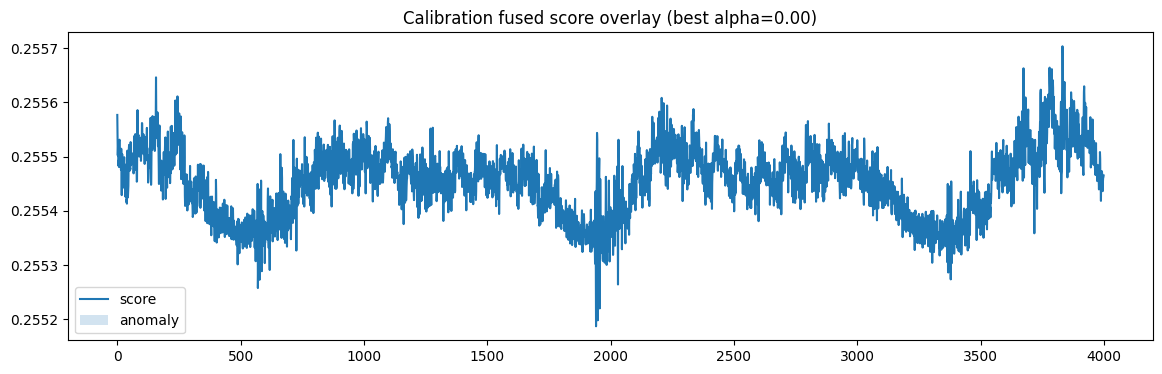

(2026-05-29 12:07:13,275) [INFO]:     [Attn_WaveletKANAD_SVDD_AlphaTuned_Holdout] handling dataset SMD_HybridHoldout | curve machine-3-7 
INFO:logger:    [Attn_WaveletKANAD_SVDD_AlphaTuned_Holdout] handling dataset SMD_HybridHoldout | curve machine-3-7 
Valid 1: 100%|██████████| 224/224 [00:03<00:00, 71.76it/s]


Epoch 1 | train_loss=131.764493 | valid_loss=108.667938 | pred=131.763392 | svdd=0.011015


Valid 2: 100%|██████████| 224/224 [00:03<00:00, 71.62it/s]


Epoch 2 | train_loss=82.802062 | valid_loss=63.754699 | pred=82.801693 | svdd=0.003699


Valid 3: 100%|██████████| 224/224 [00:03<00:00, 73.02it/s]


...

Valid 45: 100%|██████████| 224/224 [00:03<00:00, 72.39it/s]


Epoch 45 | train_loss=13.681456 | valid_loss=13.857881 | pred=13.681453 | svdd=0.000033


Valid 46: 100%|██████████| 224/224 [00:03<00:00, 72.26it/s]


Epoch 46 | train_loss=13.661352 | valid_loss=13.982385 | pred=13.661349 | svdd=0.000028


Train 47:  96%|█████████▌| 214/224 [00:12<00:00, 17.46it/s]

In [ ]:
# Cell 10 — Run the EasyTSAD experiment on the holdout dataset

gctrl = TSADController()

gctrl.set_dataset(
    dataset_type="MTS",
    dirname="/content/KAN-AD/datasets",
    datasets=[CUSTOM_DATASET],
)

# ✅ FIXED: must match class name in Cell 8
METHOD_NAME = "Attn_WaveletKANAD_SVDD_AlphaTuned_Holdout"

TRAINING_SCHEMA = "naive"

gctrl.run_exps(
    method=METHOD_NAME,
    training_schema=TRAINING_SCHEMA,
    cfg_path=CFG_PATH,
)

gctrl.set_evals([
    PointF1PA(),
    EventF1PA(mode="squeeze"),
    PointKthF1PA(k=5),
    PointAuprcPA(),
])

gctrl.do_evals(
    method=METHOD_NAME,
    training_schema=TRAINING_SCHEMA,
)

In [ ]:
# Cell 11 — Load and display EasyTSAD evaluation results

BASE_EVAL = "/content/KAN-AD/Results/Evals"
if not os.path.exists(BASE_EVAL):
    BASE_EVAL = "/content/KAN-AD/KAN-AD/Results/Evals"

avg_files = glob.glob(os.path.join(BASE_EVAL, "**", CUSTOM_DATASET, "avg.json"), recursive=True)
all_files = glob.glob(os.path.join(BASE_EVAL, "**", CUSTOM_DATASET, "all.json"), recursive=True)

print("Found avg.json:", avg_files)
print("Found all.json:", all_files)

assert avg_files, "avg.json not found"
assert all_files, "all.json not found"

avg_path = avg_files[0]
all_path = all_files[0]

with open(avg_path, "r") as f:
    avg = json.load(f)

with open(all_path, "r") as f:
    all_scores = json.load(f)

print("\n=== AVERAGE RESULTS (SMD holdout final test, averaged over machines) ===")
for k, v in avg.items():
    print(f"{k}: {v}")

print("\n=== PER-MACHINE RESULTS ===")
print("Number of machines:", len(all_scores))
if len(all_scores) > 0:
    print("Example entry:", list(all_scores.items())[0])


In [ ]:
# Cell 12 — Optional: inspect runtime stats and selected alpha

BASE_RUNTIME = "/content/KAN-AD/Results/RunTime"
if not os.path.exists(BASE_RUNTIME):
    BASE_RUNTIME = "/content/KAN-AD/KAN-AD/Results/RunTime"

runtime_files = glob.glob(
    os.path.join(BASE_RUNTIME, "**", METHOD_NAME, TRAINING_SCHEMA, CUSTOM_DATASET, "*.json"),
    recursive=True
)
print("Runtime files:", runtime_files[:5])
print("Number of runtime files:", len(runtime_files))

for fp in runtime_files[:5]:
    print("\n---", fp, "---")
    try:
        print(json.dumps(json.load(open(fp, "r")), indent=2)[:3000])
    except Exception as e:
        print("Could not read:", e)


In [ ]:
# Cell 13 — Save a compact summary for thesis/report comparison

summary_row = {
    "model": METHOD_NAME,
    "dataset": CUSTOM_DATASET,
    "original_dataset": "SMD",
    "training_schema": TRAINING_SCHEMA,
    "config_path": CFG_PATH,
    "window": 96,
    "order": 2,
    "lambda_svdd": 0.1,
    "emb_dim": 64,
    "n_features": 38,
    "num_machines": len(summary_rows),
    "calibration_dir": CALIB_DIR,
    "final_test_dir": custom_dataset_dir,
}

# Add evaluation metrics
for k, v in avg.items():
    summary_row[k] = v

summary_path = f"/content/{METHOD_NAME}_{CUSTOM_DATASET}_summary.json"

with open(summary_path, "w") as f:
    json.dump(summary_row, f, indent=2)

print("Saved summary to:", summary_path)

print("\nSummary row:")
for k, v in summary_row.items():
    print(f"{k}: {v}")
